# 02 – Preprocesare, antrenare, comparare și evaluare
**Autor:** Cristiana-Raluca Costache

Folosesc scripturile din `src/`, ca notebook-ul și proiectul să aibă **exact aceeași logică**:
- `data_preprocessing.py`: ce coloane intră în model și cum sunt transformate;
- `model_comparison.py`: 6 variante de modele pe aceleași date de train/test;
- `model_training.py`: modelul final;
- `model_evaluation.py`: metrici și interpretare.

In [1]:
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")
from config import MODEL_PATH
from data_preprocessing import CATEGORICAL_FEATURES, NUMERIC_FEATURES, build_preprocessor, get_train_test
from model_comparison import compare_models
from model_evaluation import error_by_price_range, examples_table, regression_metrics
from model_training import load_prepared_data
from predict_price import EXAMPLE_CAR, predict_price

sns.set_theme(style="whitegrid")

## 1. Preprocesare
- **Numerice** (`car_age`, `mileage_km`, `mileage_per_year`, `engine_volume_liters`, `is_high_mileage`, `is_newer_car`):
  valorile lipsă sunt completate cu **mediana** (`SimpleImputer`). Pentru modelul liniar urmează și **StandardScaler**.
- **Categorice** (`make`, `brand_model`, `condition`, `fuel_type`, `color`, `transmission`, `drive_unit`, `segment`):
  valorile lipsă devin categoria **„unknown”**. Nu le șterg: și „nu se știe segmentul” poate fi o informație.
  - pentru **Linear Regression**: **OneHotEncoder**, cu categoriile rare (< 5 anunțuri) grupate;
  - pentru **arbori**: **OrdinalEncoder**. Cu ~1.000 de modele, one-hot ar crea sute de coloane și ar fi foarte lent,
    iar arborii se descurcă bine și cu categorii codificate ca numere.

In [2]:
df = load_prepared_data()
X_train, X_test, y_train, y_test = get_train_test(df)
print("Train:", X_train.shape, "| Test:", X_test.shape)
for kind in ["linear", "tree"]:
    print(f"Coloane după preprocesarea '{kind}':", build_preprocessor(kind).fit_transform(X_train).shape[1])

[curățare] rânduri: 56244 → 55856 (eliminate 388)
Train: (44684, 14) | Test: (11172, 14)


Coloane după preprocesarea 'linear': 763
Coloane după preprocesarea 'tree': 14


## 2. Compararea modelelor
Toate modelele folosesc **aceeași împărțire** 80/20 (`random_state=42`). Primul rând este un *baseline*:
Linear Regression pe prețul brut, ca să văd cât ajută antrenarea pe log(preț). Durează ~2 minute.

In [3]:
results = compare_models()
results.round({"MAE": 0, "MSE": 0, "RMSE": 0, "R2": 3, "MedAPE_%": 1})

[curățare] rânduri: 56244 → 55856 (eliminate 388)


[OK] Linear Regression (preț brut)


[OK] Linear Regression (log preț)


[OK] Decision Tree


[OK] Random Forest


[OK] Gradient Boosting (setări implicite)


[OK] Gradient Boosting (final, reglat)


,Model,MAE,MSE,RMSE,R2,MedAPE_%,Timp (s)
0,"Gradient Boosting (final, reglat)",1023.0,4038684.0,2010.0,0.931,12.5,68.2
1,Random Forest,1085.0,5373192.0,2318.0,0.908,12.5,8.8
2,Linear Regression (log preț),1167.0,6185408.0,2487.0,0.894,13.6,1.6
3,Decision Tree,1302.0,7584947.0,2754.0,0.870,14.8,0.4
4,Gradient Boosting (setări implicite),1409.0,7737039.0,2782.0,0.867,17.1,5.7
5,Linear Regression (preț brut),1920.0,12531236.0,3540.0,0.785,23.0,1.8


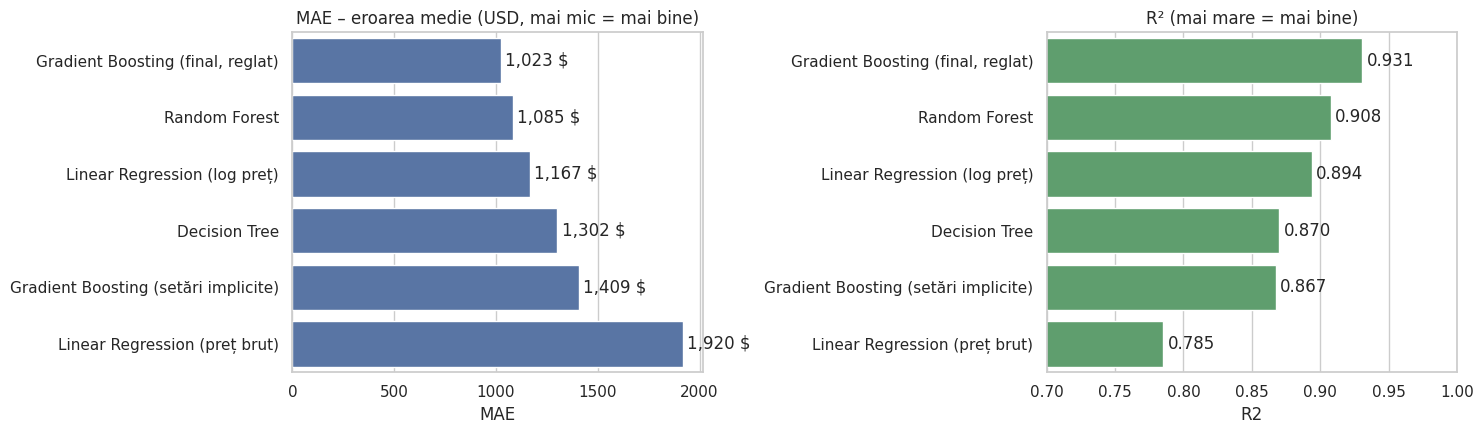

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
order = results.sort_values("MAE")
sns.barplot(data=order, y="Model", x="MAE", ax=axes[0], color="#4C72B0")
axes[0].set_title("MAE – eroarea medie (USD, mai mic = mai bine)"); axes[0].set_ylabel("")
for i, v in enumerate(order["MAE"]):
    axes[0].text(v + 20, i, f"{v:,.0f} $", va="center")
sns.barplot(data=order, y="Model", x="R2", ax=axes[1], color="#55A868")
axes[1].set_title("R² (mai mare = mai bine)"); axes[1].set_ylabel(""); axes[1].set_xlim(0.7, 1)
for i, v in enumerate(order["R2"]):
    axes[1].text(v + 0.003, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()

**Ce observ:**
- **Log(preț) contează enorm:** același Linear Regression scade de la ~1.920 $ la ~1.170 $ MAE doar prin antrenarea pe log(preț).
- **Decision Tree** e cel mai rapid, dar un singur arbore face overfitting: e mai slab decât Random Forest și chiar decât regresia liniară pe log(preț).
- **Random Forest** (media a 100 de arbori) e mult mai stabil decât un singur arbore.
- **Gradient Boosting cu setări implicite** a fost o surpriză negativă: doar 100 de arbori de adâncime 3 sunt prea puțini
  pentru ~1.000 de modele de mașini, deci modelul „nu a învățat destul” (underfitting).
- **Gradient Boosting reglat** (800 de arbori, adâncime 6, `subsample=0.8`) are **cel mai mic MAE, cel mai mic RMSE
  și cel mai mare R²**. Pe lângă asta, fișierul lui e mic (~6 MB), pe când un Random Forest salvat are peste 50 MB.
  Asta contează pentru GitHub și pentru o aplicație reală.

**Model final: Gradient Boosting reglat**, antrenat pe log(preț).

## 3. Evaluarea modelului final

In [5]:
model = joblib.load(MODEL_PATH)       # salvat de src/model_training.py
y_pred = model.predict(X_test)
m = regression_metrics(y_test, y_pred)
pd.Series(m).round(3)

MAE            1022.839
MSE         4038684.121
RMSE           2009.648
R2                0.931
MedAPE_%         12.527
dtype: float64

**Cum interpretez metricile:**
- **MAE ≈ 1.000 $**: în medie, estimarea diferă de prețul real cu aproximativ 1.000 $, la un preț median de ~5.300 $.
- **Eroarea procentuală mediană ≈ 12–13%**: pentru o mașină tipică, estimarea e la ±12% de prețul din anunț.
  E un rezultat bun, dacă ținem cont că și vânzătorii pun prețuri subiective.
- **RMSE ≈ 2× MAE**: există câteva greșeli mari. Le caut mai jos.
- **R² ≈ 0,93**: modelul explică ~93% din variația prețurilor.

In [6]:
examples_table(y_test, y_pred, n=12)

,preț real,preț estimat,eroare
0,5800,4557,1243
1,500,973,473
2,1650,505,1145
3,5500,6294,794
4,34900,32801,2099
5,3800,3273,527
6,4200,4650,450
7,6000,7164,1164
8,8600,9155,555
9,8300,7148,1152


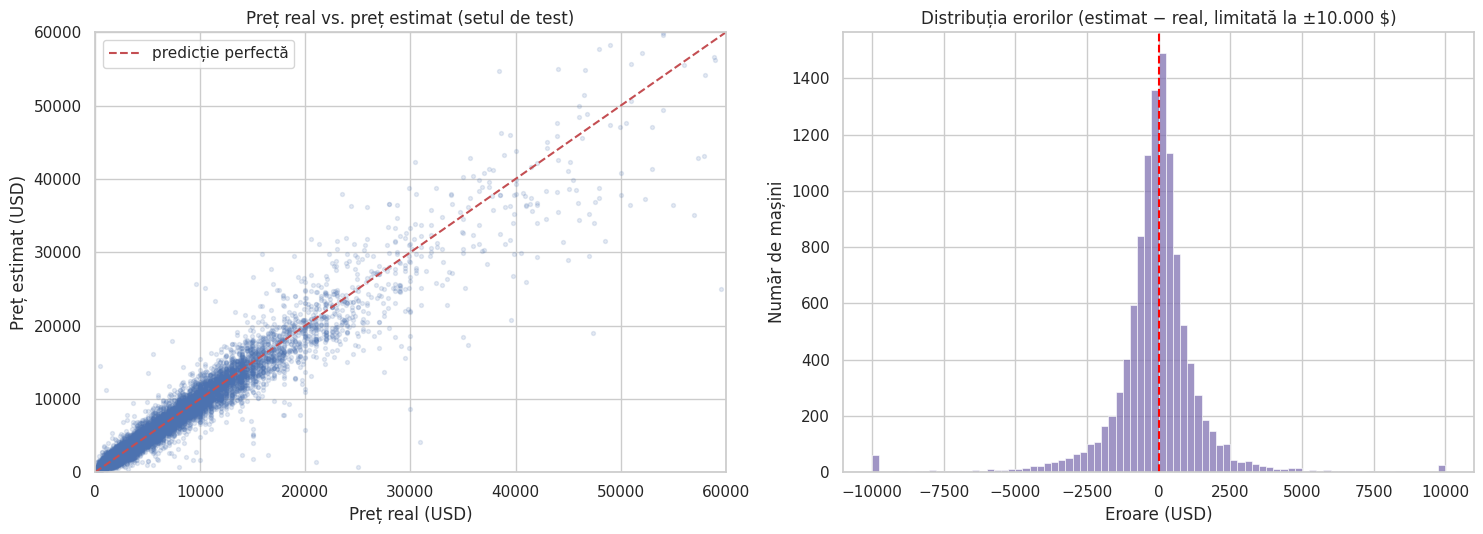

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].scatter(y_test, y_pred, alpha=.15, s=8)
lim = [0, 60000]
axes[0].plot(lim, lim, "r--", label="predicție perfectă")
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_title("Preț real vs. preț estimat (setul de test)")
axes[0].set_xlabel("Preț real (USD)"); axes[0].set_ylabel("Preț estimat (USD)"); axes[0].legend()

residuals = y_pred - y_test
sns.histplot(residuals.clip(-10000, 10000), bins=80, ax=axes[1], color="#8172B2")
axes[1].axvline(0, color="red", ls="--")
axes[1].set_title("Distribuția erorilor (estimat − real, limitată la ±10.000 $)")
axes[1].set_xlabel("Eroare (USD)"); axes[1].set_ylabel("Număr de mașini")
plt.tight_layout(); plt.show()

In [8]:
error_by_price_range(y_test, y_pred)

,mașini,MAE,preț_mediu,MAE % din preț
interval preț ($),,,,
< 3k,3536,432.0,1570.0,28.0
3k–7k,3380,712.0,4967.0,14.0
7k–15k,3133,1167.0,10388.0,11.0
15k–30k,934,2616.0,20007.0,13.0
> 30k,189,7368.0,44833.0,16.0


**Unde greșește modelul?**
- **Eroarea în dolari crește cu prețul** (~400 $ sub 3.000 $, mii de dolari peste 30.000 $). În procente însă rămâne relativ stabilă.
- **Mașinile ieftine (< 3.000 $)** au cea mai mare eroare procentuală. Aici apar des mașinile „for parts” sau „with damage”,
  la care prețul depinde de detalii care nu sunt în date (ce anume e stricat).
- **Mașinile scumpe** sunt puține în date, deci modelul are mai puține exemple din care să învețe.

In [9]:
# Cele mai mari greșeli – ce au în comun?
worst = X_test.assign(pret_real=y_test.values, pret_estimat=y_pred.round(),
                      eroare=np.abs(y_pred - y_test.values)).nlargest(10, "eroare")
worst[["brand_model", "car_age", "mileage_km", "condition", "segment", "pret_real", "pret_estimat", "eroare"]]

,brand_model,car_age,mileage_km,condition,segment,pret_real,pret_estimat,eroare
5748,porsche_911,12,45000.0,with mileage,S,59500,24954.0,34545.947688
42969,lexus_rx,4,50000.0,with mileage,J,63500,34390.0,29109.914245
43478,mercedes-benz_s-klass,29,64000.0,with mileage,S,47400,18992.0,28408.123207
8976,bmw_5-seriya,2,5500.0,with mileage,E,82326,54697.0,27629.176777
30968,renault_laguna,17,323000.0,with mileage,D,30898,4096.0,26802.154818
10146,bmw_7-seriya,2,37000.0,with mileage,F,87000,61039.0,25961.442792
43564,mercedes-benz_s-klass-amg,7,157000.0,with mileage,S,67000,41999.0,25000.650236
906,gaz_24,40,NaN,with mileage,E,25000,742.0,24258.477308
10239,bmw_7-seriya,4,44000.0,with mileage,F,74900,50913.0,23987.011592
43362,mercedes-benz_s-klass,5,105000.0,with mileage,S,73000,50396.0,22604.381103


**Cele mai mari greșeli** sunt de două tipuri:
1. **Mașini premium scumpe** (Porsche 911, Mercedes S-Klasse, BMW seria 7, Lexus RX): modelul le **subestimează**,
   pentru că sunt puține în date și prețul lor depinde mult de dotări, care nu apar în date.
   
2. **Anunțuri probabil greșite sau speciale**: un Renault Laguna si un GAZ-24 (Volga)

## 4. Ce caracteristici contează cel mai mult?

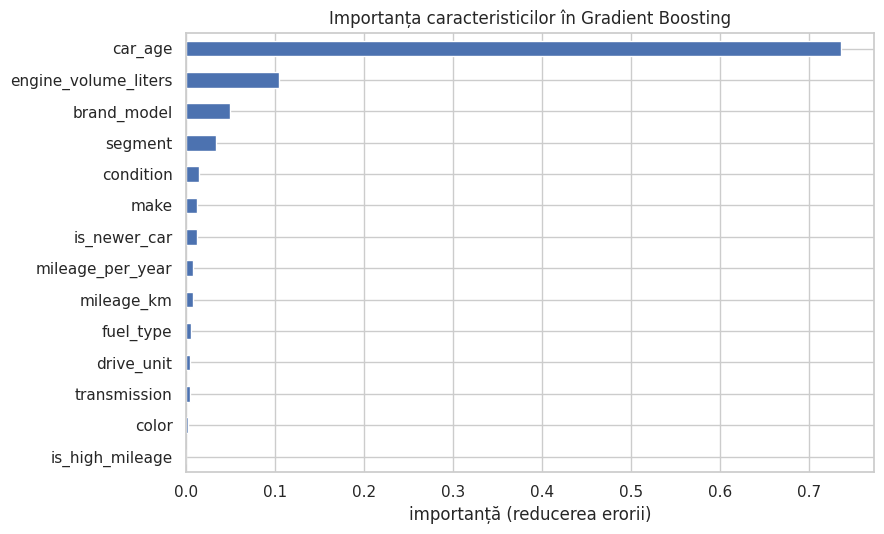

In [10]:
gbr = model.named_steps["model"].regressor_
names = NUMERIC_FEATURES + CATEGORICAL_FEATURES
importance = pd.Series(gbr.feature_importances_, index=names).sort_values()
plt.figure(figsize=(9, 5.5))
importance.plot(kind="barh", color="#4C72B0")
plt.title("Importanța caracteristicilor în Gradient Boosting"); plt.xlabel("importanță (reducerea erorii)")
plt.tight_layout(); plt.show()

- **`car_age` domină** (~74% din importanță). Vârsta este de departe cel mai important factor de preț.
- Urmează **capacitatea motorului** (~10%), **`brand_model`** (~5%), **segmentul** și **starea**.
- **Surpriză:** kilometrajul (`mileage_km`, `mileage_per_year`) are importanță mică. Cred că informația lui este în mare parte
  deja „conținută” de vârstă, iar în date kilometrajul declarat e adesea nesigur (vezi valorile ciudate din EDA).
- `is_high_mileage` are importanță ~0: arborii își găsesc singuri pragul din `mileage_km`, deci indicatorul e redundant.
  L-am păstrat pentru transparență, dar într-o versiune următoare l-aș scoate. Nu orice caracteristică nouă ajută.

## 5. Exemplul din enunț: VW Golf 2014, diesel, 180.000 km

In [11]:
price = predict_price(model, EXAMPLE_CAR)
print(f"Preț estimat: {price:,.0f} $")

raw_like = df[(df["brand_model"] == "volkswagen_golf") & (df["year"] == 2014) & (df["fuel_type"] == "diesel")]
raw_like[["year", "mileage_km", "engine_volume_liters", "transmission", "price_usd"]]

Preț estimat: 11,992 $


,year,mileage_km,engine_volume_liters,transmission,price_usd
27010,2014,170000.0,1.6,mechanics,14260
27116,2014,160000.0,1.6,mechanics,10777
27352,2014,190386.0,1.6,mechanics,13150
27510,2014,168000.0,1.6,mechanics,10900
27593,2014,260000.0,1.6,mechanics,10500


Modelul estimează **~12.000 $**. Enunțul dă ca exemplu ~9.990 $, dar în setul nostru cele 5 Golf-uri diesel din 2014,
cu 160.000-260.000 km, sunt listate între **10.500 și 14.260 $** (mediană 10.900 $). Estimarea modelului este deci
**în intervalul real al pieței din date**.

## 6. Concluzii
| | |
|---|---|
| **Model final** | Gradient Boosting Regressor (800 arbori, adâncime 6), antrenat pe log(preț) |
| **MAE** | ~1.020 $ |
| **RMSE** | ~2.010 $ |
| **R²** | ~0,93 |
| **Eroare procentuală mediană** | ~12,5% |

**Ce am învățat:**
1. **Curățarea a fost esențială.** Kilometraje de 9.999.999 km și motoare de 20.000 cm³ ar fi încurcat modelul.
2. **Transformarea țintei (log) a adus cel mai mare câștig**, mai mare decât schimbarea algoritmului.
3. **Setările contează:** Gradient Boosting cu parametrii impliciți a fost printre cele mai slabe modele, iar reglat a fost cel mai bun.

**Ce aș îmbunătăți:**
- căutarea sistematică a parametrilor (`GridSearchCV` / `RandomizedSearchCV`) și validare încrucișată;
- un interval de încredere în loc de un singur preț (ex. „între 10.800 și 13.200 $”);
- informații care lipsesc acum: echipare, număr de proprietari, regiune.